## Company Var Explorer

In this notebook I explore all the variables in the filtered BB/SME dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)

In [2]:
INPUT_PATH  = "../data/processed/filtered_bb_sme_sectors.zip"
DATE_COLS = [
    "IncorporationDate",
    "Accounts.NextDueDate",
    "Accounts.LastMadeUpDate",
    "ConfStmtNextDueDate",
    "ConfStmtLastMadeUpDate",
] + [f"PreviousName_{i}.CONDATE" for i in range(1, 11)]

In [ ]:
# Reading bulk CSV
df = pd.read_csv(INPUT_PATH, low_memory=False)
df.columns = df.columns.str.strip()

for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")

print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")

### 0. Dataset overview

In [26]:
df.dtypes

CompanyName                                      str
CompanyNumber                                    str
RegAddress.CareOf                                str
RegAddress.POBox                                 str
RegAddress.AddressLine1                          str
RegAddress.AddressLine2                          str
RegAddress.PostTown                              str
RegAddress.County                                str
RegAddress.Country                               str
RegAddress.PostCode                              str
CompanyCategory                                  str
CompanyStatus                                    str
CountryOfOrigin                                  str
DissolutionDate                              float64
IncorporationDate                     datetime64[us]
Accounts.AccountRefDay                       float64
Accounts.AccountRefMonth                     float64
Accounts.NextDueDate                  datetime64[us]
Accounts.LastMadeUpDate               datetime

In [13]:
null_summary = (
    df.isnull().sum().rename('null_count').to_frame()
)

In [14]:
null_summary['null_pct'] = (null_summary['null_count'] / len(df) * 100).round(1)
null_summary['dtype'] = df.dtypes
null_summary.sort_values('null_pct', ascending=False)

,null_count,null_pct,dtype
DissolutionDate,869043,100.0,float64
PreviousName_9.CONDATE,869028,100.0,datetime64[us]
PreviousName_9.CompanyName,869028,100.0,str
PreviousName_10.CONDATE,869034,100.0,datetime64[us]
PreviousName_10.CompanyName,869034,100.0,str
PreviousName_7.CONDATE,868989,100.0,datetime64[us]
PreviousName_7.CompanyName,868989,100.0,str
PreviousName_8.CONDATE,869013,100.0,datetime64[us]
PreviousName_8.CompanyName,869013,100.0,str
PreviousName_5.CONDATE,868721,100.0,datetime64[us]


### 1. Identifiers

`CompanyName`, `CompanyNumber` and `URI` are metadata fields and carry no distributional signal. Aside from being unique for each company.

In [15]:
print("Rows:", len(df))
print("Unique CompanyNumbers:", df['CompanyNumber'].nunique())
print("Unique CompanyNames:", df['CompanyName'].nunique())
print("\nSample company numbers:")
print(df['CompanyNumber'].head(10).tolist())
print("\nSample URIs:")
print(df['URI'].head(3).tolist())

Rows: 869043
Unique CompanyNumbers: 869043
Unique CompanyNames: 869043

Sample company numbers:
['15073164', '13522064', '11006939', '02537158', '01382560', '14502415', '15081740', '09102217', '01941022', '03606467']

Sample URIs:
['http://business.data.gov.uk/id/company/15073164', 'http://business.data.gov.uk/id/company/13522064', 'http://business.data.gov.uk/id/company/11006939']


### 2. Company base characterisctics

- `CompanyCategory` = governance structure; for this DB 98% PLC
- `CompanyStatus` = in this DB "Active" only
- `CountryOfOrigin` = country were the company is originally incorporated; for this DB 100% UK

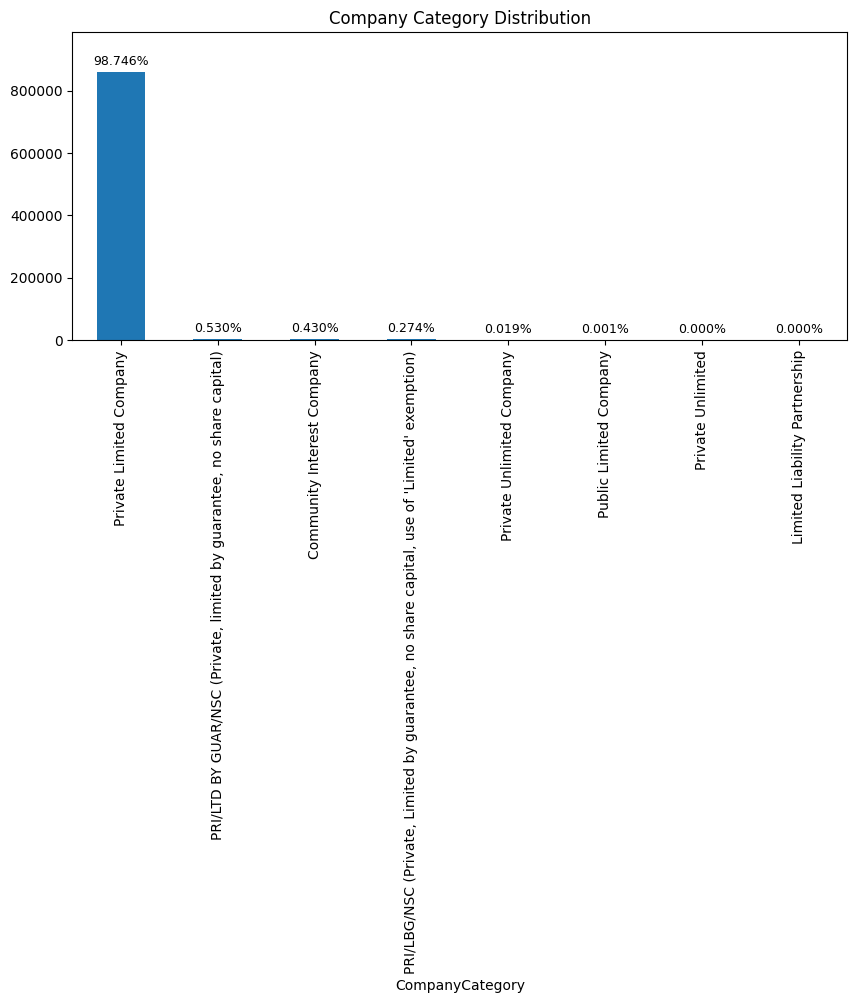

In [ ]:
counts = df["CompanyCategory"].value_counts()
total = counts.sum()

ax = counts.plot(kind="bar", figsize=(10, 4), title="Company Category Distribution")

ax.bar_label(
    ax.containers[0],
    # labels=[f"{v:,}" for v in counts], # absolute
    labels=[f"{v/total:.3%}" for v in counts], # percentages
    padding=3, fontsize=9,
)
ax.margins(y=0.15)

In [24]:
df['CountryOfOrigin'].value_counts()

CountryOfOrigin
United Kingdom    869043
Name: count, dtype: int64